### `Task` How dimensionality reduction using Principal Component Analysis (PCA) on the Wine Quality dataset contributes to improving the classification accuracy and efficiency of wine type.

Note : Use KNN for Classification.

Data Link :  [Wine Data](https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv)

# import Libraties 

In [ ]:
# Data Loading
import pandas as pd
wine_data_path = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv"
wine = pd.read_csv(wine_data_path)
wine.head(1)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.001,3.0,0.45,8.8,6


In [ ]:
# Your Code goes Here

In [12]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
X = load_wine(as_frame=True)['data']
y = load_wine(as_frame=True)['target']


In [5]:
# features
X

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [6]:
# target
y

0      0
1      0
2      0
3      0
4      0
      ..
173    2
174    2
175    2
176    2
177    2
Name: target, Length: 178, dtype: int32

In [ ]:
# so we have multi classification problem 
y.unique()

array([0, 1, 2])

# Eda

In [11]:
X.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')

In [10]:
enumerate(X.columns)

## histogram

In [18]:
len(X.columns)

13

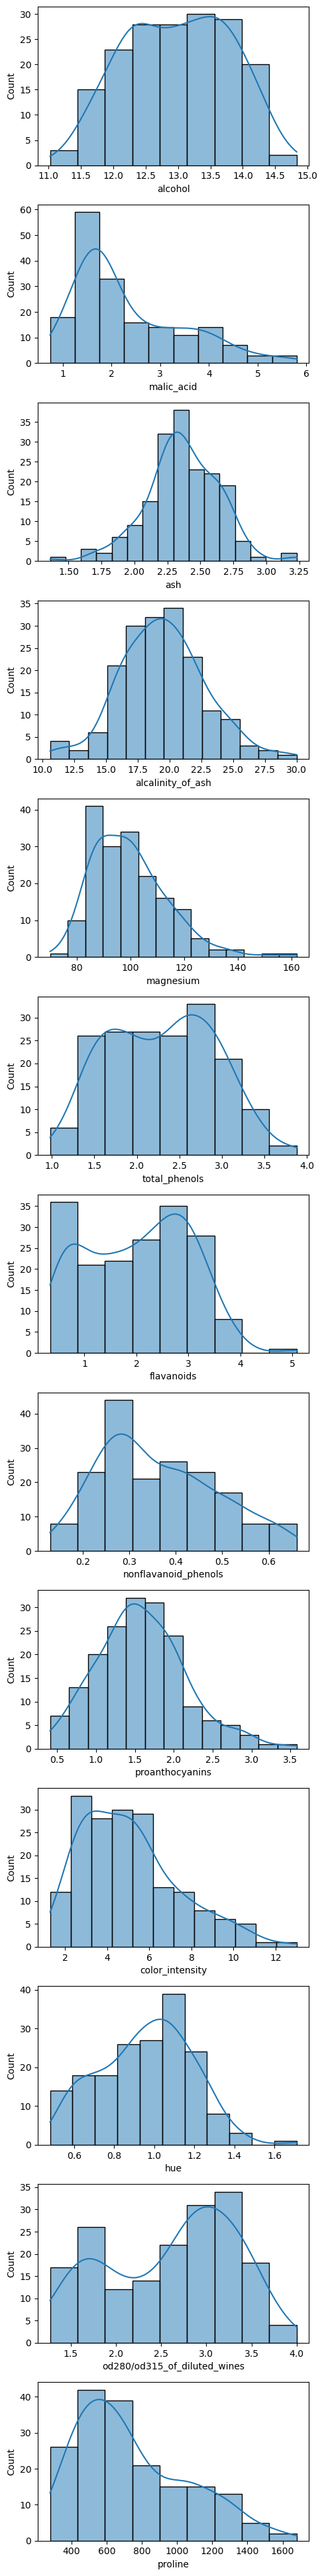

In [25]:

# Create a grid layout matching your feature count
fig, axes = plt.subplots(len(X.columns), 1, figsize=(5, 3 * len(X.columns)))

for i, col in enumerate(X.columns):
    sns.histplot(data=X, x=col,kde=True, ax=axes[i])

plt.tight_layout()
    

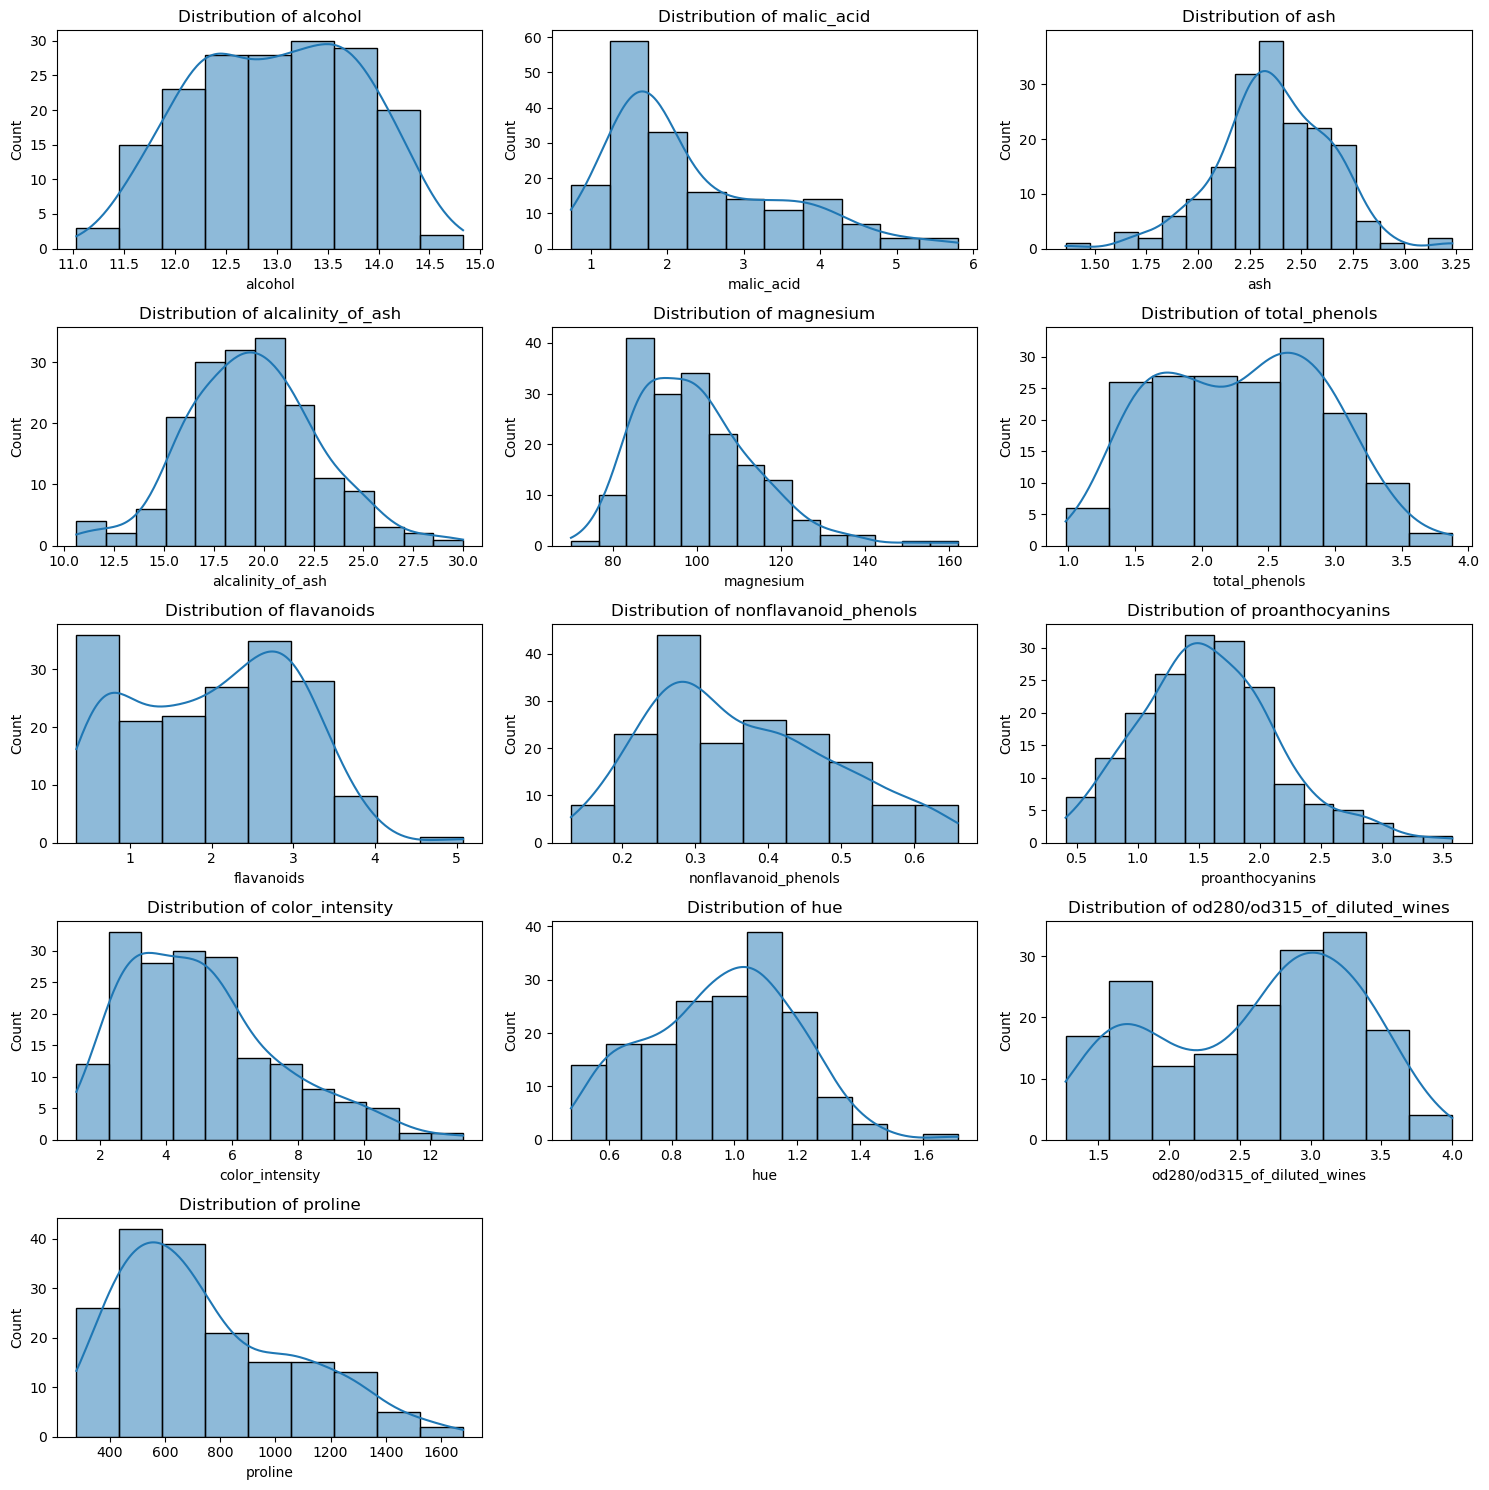

In [30]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dynamically calculate the required grid size
n_cols = 3  # Choose how many columns wide you want the grid
n_rows = math.ceil(len(X.columns) / n_cols)  # Automatically handles 13 / 3 = 5 rows

# 2. Create the 2D grid canvas
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
axes_flat = axes.flatten()  # Converts the 2D grid into a simple 1D list

# 3. Loop and plot features
for i, col in enumerate(X.columns):
    sns.histplot(data=X, x=col, kde=True, ax=axes_flat[i])
    axes_flat[i].set_title(f"Distribution of {col}")

# 4. Hide empty subplot boxes (Since 5 rows * 3 cols = 15 slots, but you only have 13 columns)
for j in range(len(X.columns), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()


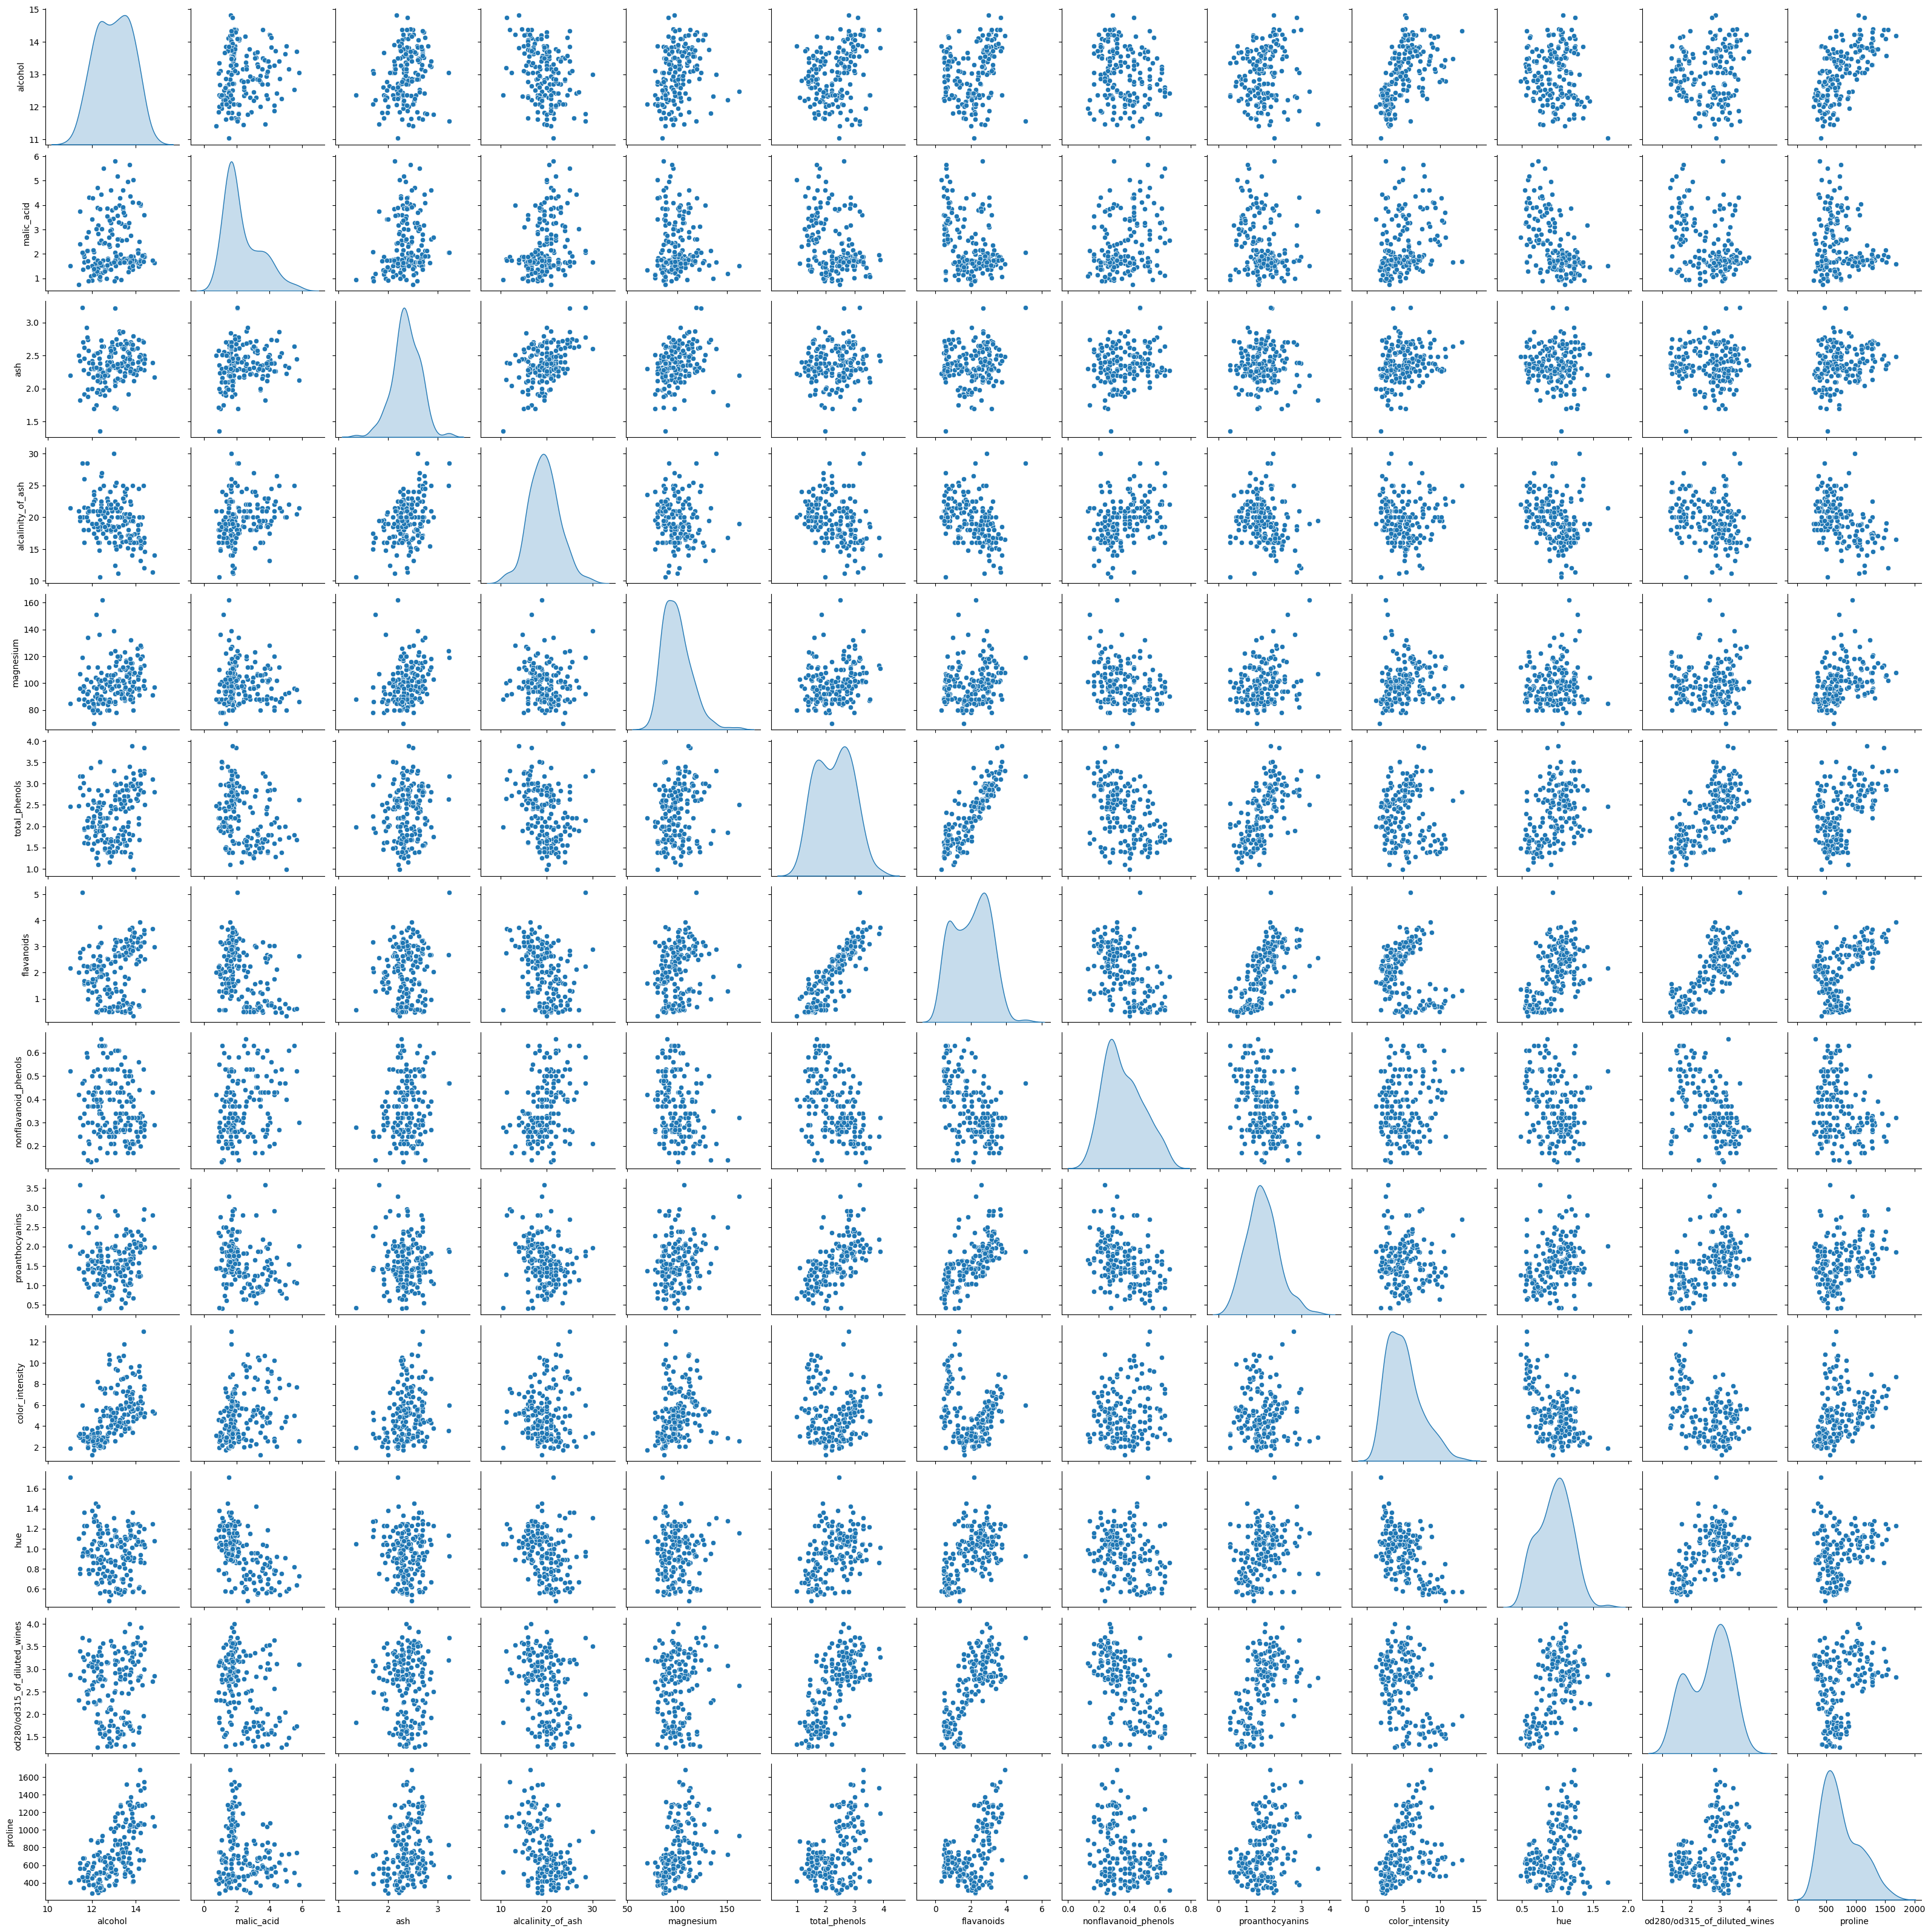

In [26]:
sns.pairplot(X, diag_kind="kde")


# train test split

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.2,
                                                    random_state=2
                                                    )

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# fit Model

In [33]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [34]:
y_pred = knn.predict(X_test)

from sklearn.metrics import accuracy_score
print('accuracy score :',accuracy_score(y_test,y_pred))

accuracy score : 0.9444444444444444


# Apply PCA

In [36]:
from sklearn.decomposition import PCA
pca = PCA(n_components=6)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


print(X_train_pca.shape)
print(X_test_pca.shape)

(142, 6)
(36, 6)


In [38]:
# appply again knn
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train_pca,y_train)


y_pred = knn.predict(X_test_pca)

from sklearn.metrics import accuracy_score
print('accuracy score :',accuracy_score(y_test,y_pred))

accuracy score : 0.9722222222222222


accuracy improves when the dimension is less . 

what happen if we do not do scaling 

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.2,
                                                    random_state=2
                                                    )


from sklearn.decomposition import PCA
pca = PCA(n_components=6)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


print(X_train_pca.shape)
print(X_test_pca.shape)

(142, 6)
(36, 6)


now fit model

In [40]:
# appply again knn
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train_pca,y_train)


y_pred = knn.predict(X_test_pca)

from sklearn.metrics import accuracy_score
print('accuracy score :',accuracy_score(y_test,y_pred))

accuracy score : 0.75


So without scaling accuracy drops predications are bad . 

you do the experimentation in ml with code then you learn more 